In [1]:
import dxpy
import pandas as pd
import numpy as np

# Undersampling
from imblearn.over_sampling import ADASYN

# Splitting Data
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# Models
from sklearn.ensemble import RandomForestClassifier
from xgboost.sklearn import XGBClassifier

# Metrics
from sklearn.metrics import (confusion_matrix, auc, roc_auc_score,
                             roc_curve, precision_recall_fscore_support,
                             ConfusionMatrixDisplay)

# Visualization 
import matplotlib.pyplot as plt


# Read File

In [2]:
# Download file
dxpy.download_dxfile('file-GpXGP18JjKX5JQvYy14J12Fx', 'file.csv')

In [3]:
# Read csv file to pandas dataframe
df = pd.read_csv('file.csv', sep='\t')

In [ ]:
# First 5 rows
df.head()

In [5]:
# shape
df.shape

(17684, 2923)

In [6]:
# Number of cases and controls
df.value_counts('status')

status
0    16331
1     1353
dtype: int64

In [7]:
# Check the number of the missing valus
df.isna().sum()

alcam       0
lilrb5      0
lilrb1      0
ccl15       0
ccl16       0
           ..
ctss        0
cst1        0
UKBB_GRS    0
grs         0
status      0
Length: 2923, dtype: int64

In [8]:
# Make input and output variables
X = df.drop(columns=['status'])
y = df['status']

# Analysis

## Data splitting

In [9]:
# Split data to train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
# Define stratified k fold cross validation with 5 folds
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## ADASyn over Sampling

In [11]:
# oversampling cases match the size of the controls
aos = ADASYN(random_state=42)
X_res, y_res = aos.fit_resample(X_train, y_train)

In [12]:
# Number of controls after undersampling
X_res[y_res==0].shape

(13065, 2922)

In [13]:
# Number of cases after undersampling
X_res[y_res==1].shape

(13247, 2922)

## Feature Selection

In [14]:
# Download important features file
dxpy.download_dxfile('file-GpY67jjJjKXB16vfqYgJPfQq', 'features.csv')

In [15]:
# Save file in pandas dataframe
features_df = pd.read_csv('features.csv', sep='\t')

In [16]:
features_df = features_df.drop(features_df.index[1])

In [17]:
# Select first 50 most important features to train the model
top_features = features_df['feature'].head(50)

In [18]:
# Filter train and test input dataframes with selected features
X_train_selected = X_res[top_features]
X_test_selected = X_test[top_features]

## Model

In [19]:
# Define parameter grid for GridSearchCV
param_grid = {
    "learning_rate": [0.05, 0.1, 0.2],
    "gamma": [0, 2],
    "objective": ['binary:logistic', 'binary:logitraw', 'binary:hinge'],
    "min_child_weight": [1],
    "subsample": [0.8, 1],
    "max_depth": [4, 6]
}

In [20]:
# Define XGBoost classifier
xg = XGBClassifier(random_state=42)

In [21]:
# Set up GridSearchCV with K-Fold Cross-Validation
grid_search = GridSearchCV(estimator=xg, param_grid=param_grid, cv=kfold,
                           scoring='recall')

In [22]:
%%time
# Fit the model
grid_search.fit(X_train_selected, y_res)

CPU times: user 28min, sys: 1.63 s, total: 28min 1s
Wall time: 1min 56s


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_typ...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             param_grid={'gamma': [0, 2], 'learning_rate': [0.05, 0.1, 0.2],
                         'max_depth': [4, 6], 'min_child_weight': [1],
                         'objective': ['binary:logistic', 'binary:logitraw',
                                       'binary:hinge'],
                         'subsample': [0.8, 1]},
             scoring='recall')

In [23]:
# Get the best parameters and recall
print(f'Best parameters: {grid_search.best_params_}')
print(f'Best score(recall): {grid_search.best_score_}')

Best parameters: {'gamma': 2, 'learning_rate': 0.2, 'max_depth': 6, 'min_child_weight': 1, 'objective': 'binary:hinge', 'subsample': 1}
Best score(recall): 0.9558389994088193


In [24]:
# Get the predicted probabilities for the positive class
y_proba = grid_search.best_estimator_.predict_proba(X_test_selected)[:, 1]

## Metrics

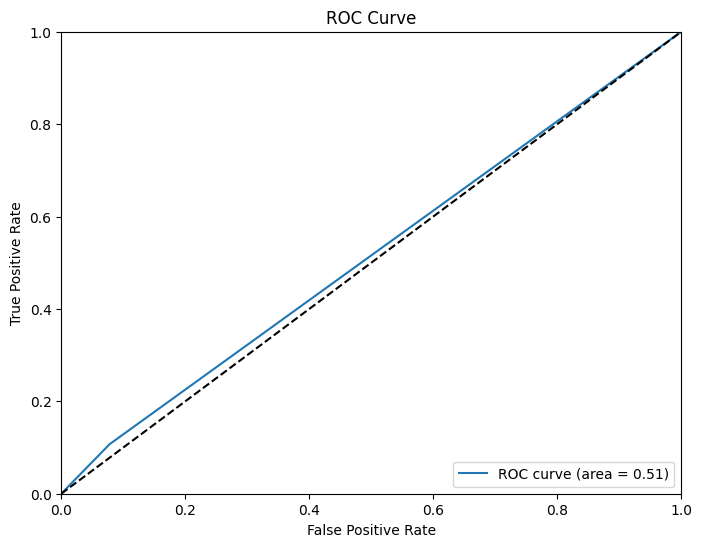

In [25]:
# ROC Curve

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test, y_proba)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC Curve')
plt.legend(loc='lower right')
# Save the plot as an image
#plt.savefig('roc_curve.png')
plt.show()

In [26]:
y_pred = grid_search.best_estimator_.predict(X_test_selected)

In [27]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred,
                                                           average='binary')
specificity = tn / (tn + fp)
g_mean = np.sqrt(recall * specificity)

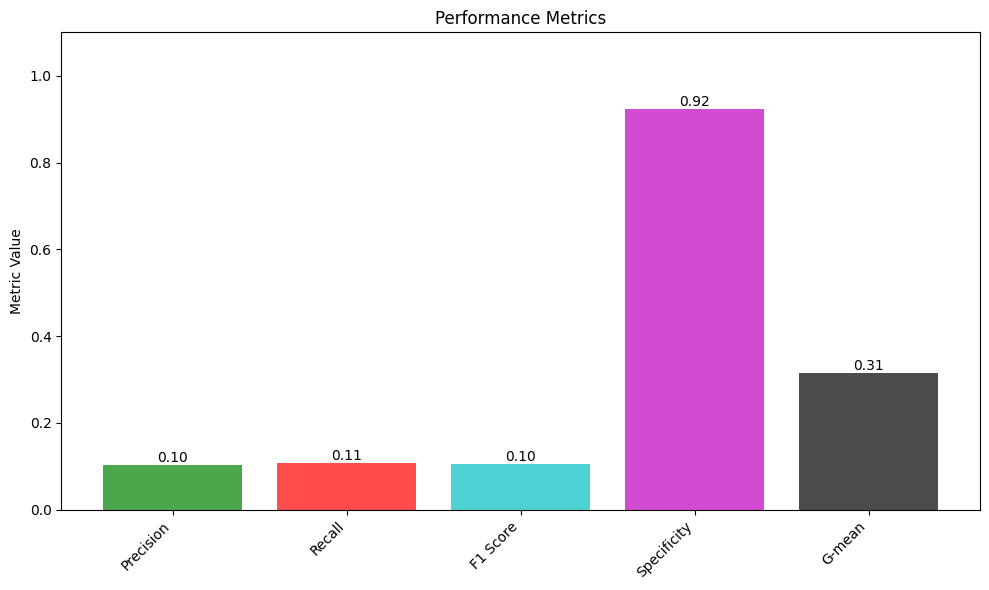

In [28]:
# Plot metrics as a bar plot
plt.figure(figsize=(10, 6))

metrics = ['Precision', 'Recall', 'F1 Score', 'Specificity', 'G-mean']
values = [precision, recall, f1, specificity, g_mean]
colors = ['g', 'r', 'c', 'm', 'black']

bars = plt.bar(metrics, values, color=colors, alpha=0.7)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=10)

plt.ylabel('Metric Value')
plt.title('Performance Metrics')
plt.ylim(0, 1.1)  # Set y-axis limit from 0 to 1.1 to accommodate labels

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

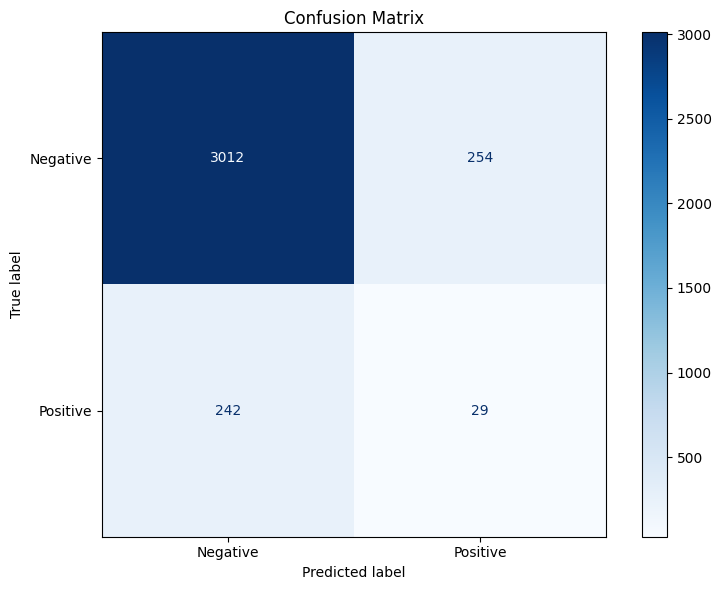

In [29]:
# Create a single plot for the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the confusion matrix using sklearn
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    ax=ax, 
    display_labels=['Negative', 'Positive'], 
    cmap='Blues'
)

# Set title and adjust layout
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()